# Set-up

## Load libraries

In [ ]:
#Set directory
directory="C:/Users/atanoh/Documents/2026/CA125"
setwd(directory)
#Install and load libraires
invisible(source("./src/install_librairies.r"))
install_packages(directory)
invisible(source("./src/load_librairies.r"))
# Load functions
invisible(source("./src/functions.r"))

Installation du package dans 'C:/Users/atanoh/AppData/Local/R/win-library/4.5'
(car 'lib' n'est pas spécifié)

installation des dépendances 'sys', 'askpass', 'rappdirs', 'curl', 'mime', 'openssl', 'farver', 'labeling', 'RColorBrewer', 'viridisLite', 'cachem', 'sass', 'bit', 'diffobj', 'pkgconfig', 'backports', 'stringr', 'httr', 'blob', 'gtable', 'isoband', 'S7', 'scales', 'prettyunits', 'bslib', 'fontawesome', 'jquerylib', 'tinytex', 'bit64', 'memoise', 'brio', 'praise', 'waldo', 'generics', 'tibble', 'tidyselect', 'broom', 'covr', 'DBI', 'dbplyr', 'ggplot2', 'Lahman', 'lobstr', 'nycflights13', 'rmarkdown', 'RSQLite', 'testthat', 'tidyr'





  Une version binaire est disponible mais la version du source est plus
  récente:
        binary source needs_compilation
diffobj  0.3.6  0.3.8              TRUE

  Binaries will be installed
le package 'sys' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'askpass' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'rappdirs' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'curl' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'mime' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'openssl' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'farver' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'labeling' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'RColorBrewer' a été décompressé et les sommes MD5 ont été vérifiées avec succés
le package 'viridisLite' a 

## Load and clean dataset

In [ ]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)


n_patients,n_trials,n_measures
<int>,<int>,<int>
8219,13,102809


In [ ]:
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [ ]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [ ]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [ ]:
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
8163,13,81449


In [ ]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-factor(ifelse(ca125$os_status=='Yes', 1, 0), levels=c(0,1))
ca125["pfs_statut"]<-factor(ifelse(ca125$PFS_status=='Yes', 1, 0), levels=c(0,1))
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [ ]:
ca125_all_6 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
7933,13,47256


In [ ]:
str(ca125_all_6[, c("pfs_time_d", "pfs_statut", "trt_bin")])

tibble [47,256 × 3] (S3: tbl_df/tbl/data.frame)
 $ pfs_time_d: num [1:47256] 328 328 328 328 328 ...
 $ pfs_statut: Factor w/ 2 levels "0","1": 2 2 2 2 2 2 2 2 2 2 ...
 $ trt_bin   : num [1:47256] 1 1 1 1 1 1 1 0 0 0 ...


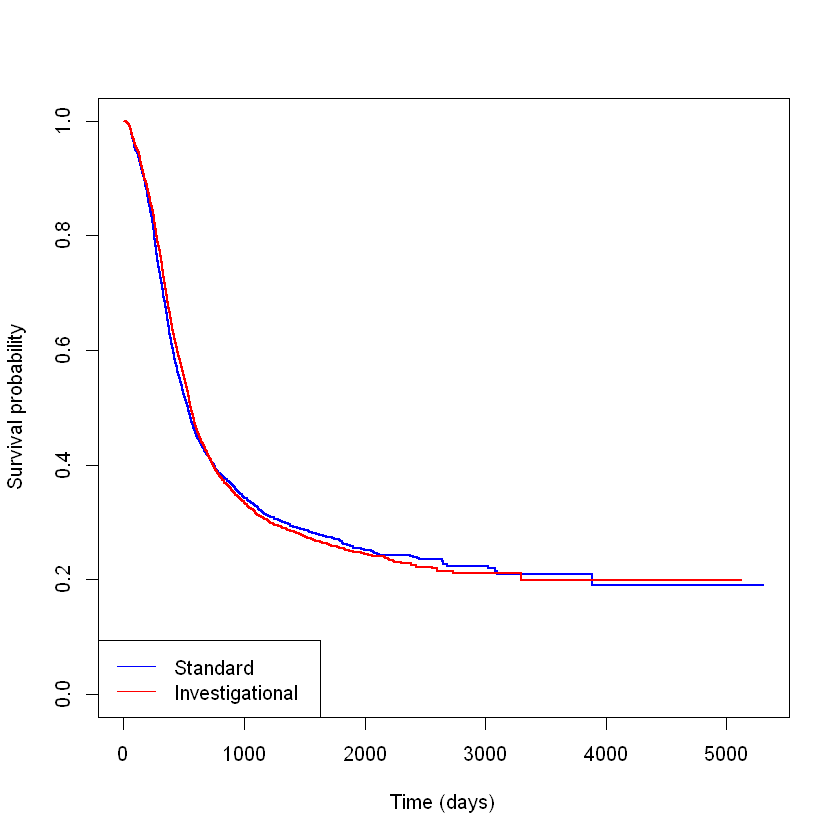

In [ ]:

#Survival vs treatment
ca125_all_6$trt_bin <- factor(ca125_all_6$trt_bin,
                         levels = c(0, 1))

km_trt <- survfit(Surv(pfs_time_d, as.numeric(as.character(pfs_statut))) ~ trt_bin,
              data = ca125_all_6[!duplicated(ca125_all_6$id), ])

plot(km_trt,
     col = c("blue", "red"),
     lwd = 2,
     xlab = "Time (days)",
     ylab = "Survival probability",
     mark.time = FALSE)

legend("bottomleft",
       legend = c("Standard", "Investigational"),
       col = c("blue", "red"),
       lwd = 1)

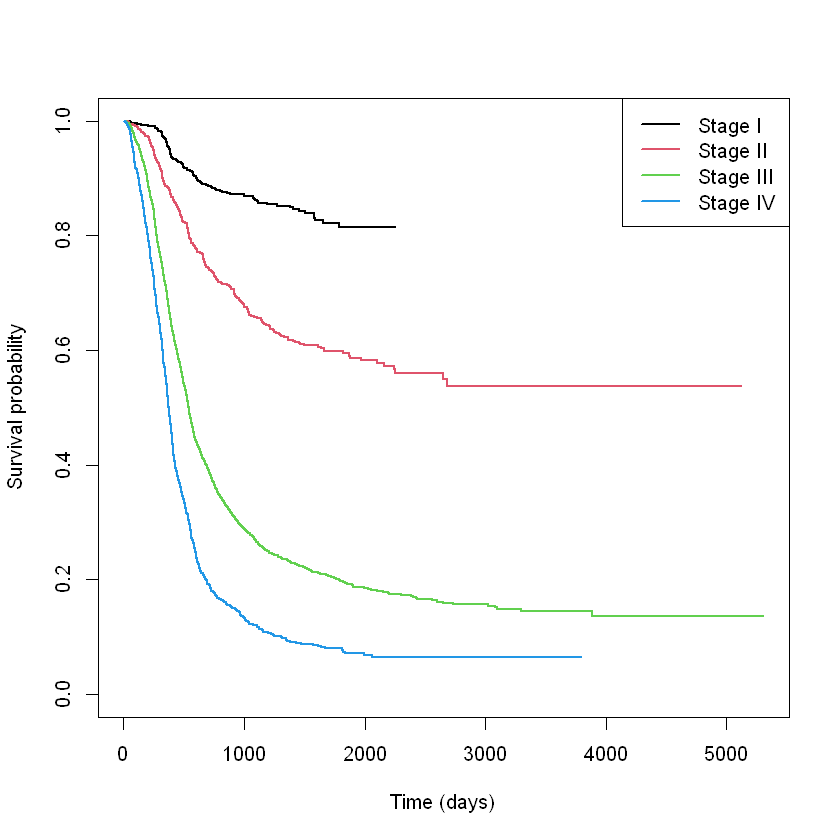

In [ ]:
#Survival vs FIGO stage

figo_data <- ca125_all_6[!duplicated(ca125_all_6$id), ] %>%
  filter(!figo %in% c("Missing", "Unknown")) %>%
  mutate(
    stage_group = case_when(
      figo %in% c("Stage I(A & B)", "Stage IC(1,2 or 3)") ~ "Stage I",
      figo %in% c("Stage II(A & B)", "Stage IIc") ~ "Stage II",
      figo %in% c("Stage III", "Stage IIIA", "Stage IIIB", "Stage IIIC") ~ "Stage III",
      figo == "Stage IV" ~ "Stage IV",
      TRUE ~ NA_character_
    ),
    pfs_statut = as.numeric(as.character(pfs_statut))
  )

km_figo <- survfit(Surv(pfs_time_d, pfs_statut) ~ stage_group,
                    data = figo_data)

plot(km_figo,
     col = 1:4,
     lwd = 2,
     xlab = "Time (days)",
     ylab = "Survival probability")

legend("topright",
       legend = levels(factor(figo_data$stage_group)),
       col = 1:4,
       lwd = 2)

**Summarise data**

In [ ]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),

     # percentage deaths
    mean_baseline = round(mean(ca125_base, na.rm = TRUE),2),
    
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

trialid,status,nb_measures,nb_patients,mean_ca125,mean_baseline,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Maintenance,648,194,96.12,31.60,17.13,52.62,330.00,267.50
CCTG-OV.16,No maintenance,5517,731,222.35,721.71,72.05,84.74,1443.99,504.99
DoCaCel,Maintenance,40,19,186.32,346.38,72.50,77.50,995.50,374.50
EORTC-55041,Maintenance,1982,772,74.86,25.07,43.90,74.42,1351.00,424.00
GINECO-2007,Intensification therapy,613,109,313.07,870.53,83.85,92.50,975.00,445.00
JGOG-3016,Intensification therapy,3240,552,312.25,1022.00,46.57,65.25,1837.00,841.00
JGOG-3017,No maintenance,3497,608,67.62,129.05,18.84,26.19,1195.00,1100.00
MITO-7,Intensification therapy,1398,517,206.89,473.78,16.95,51.65,629.00,490.00
MRC-ICON7,Maintenance,10017,1471,113.08,376.65,46.14,71.46,1493.00,576.00


*Presentation of data and variables of interest (appendix)*

In [ ]:
ca125_all_6 %>%  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

status,nb_measures,nb_patients,mean_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Intensification therapy,47256,7933,204.4,46.07,68.61,959,527


# Modeling CA125

## Evolution of CA-125

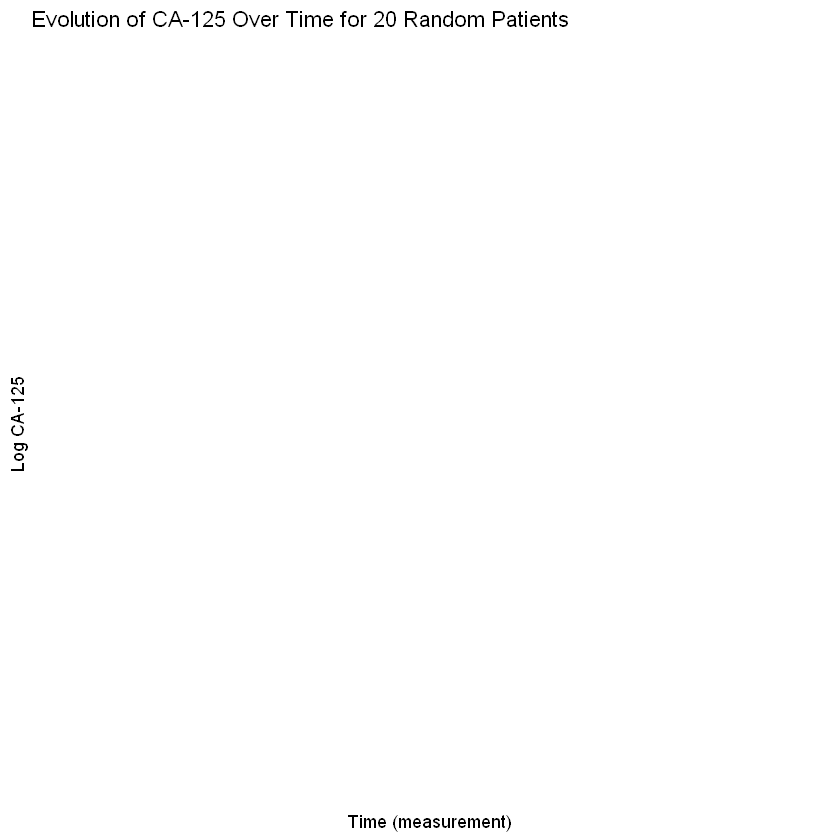

In [ ]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [ ]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)



decreasing increasing 
     43446       3810 

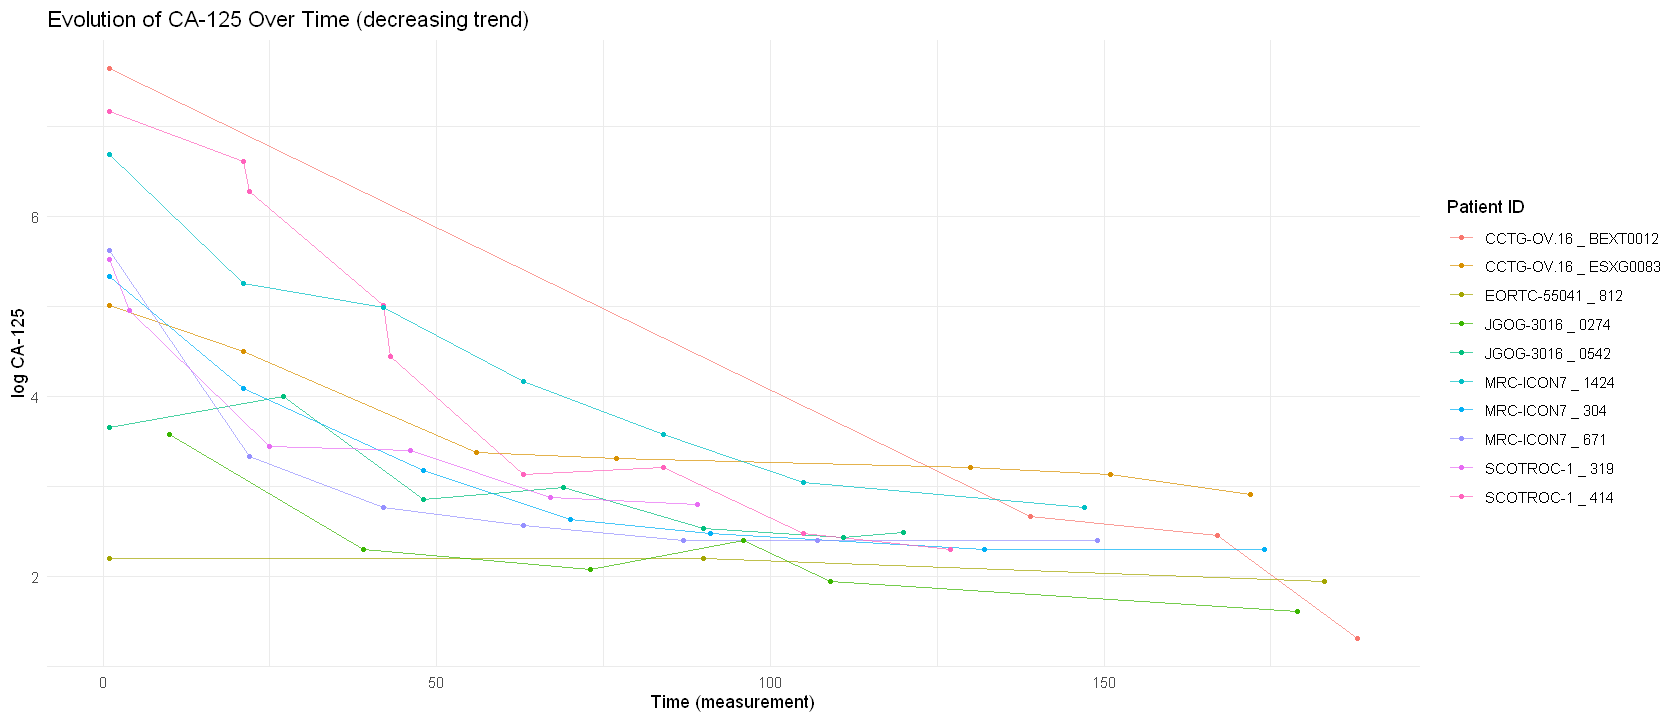

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

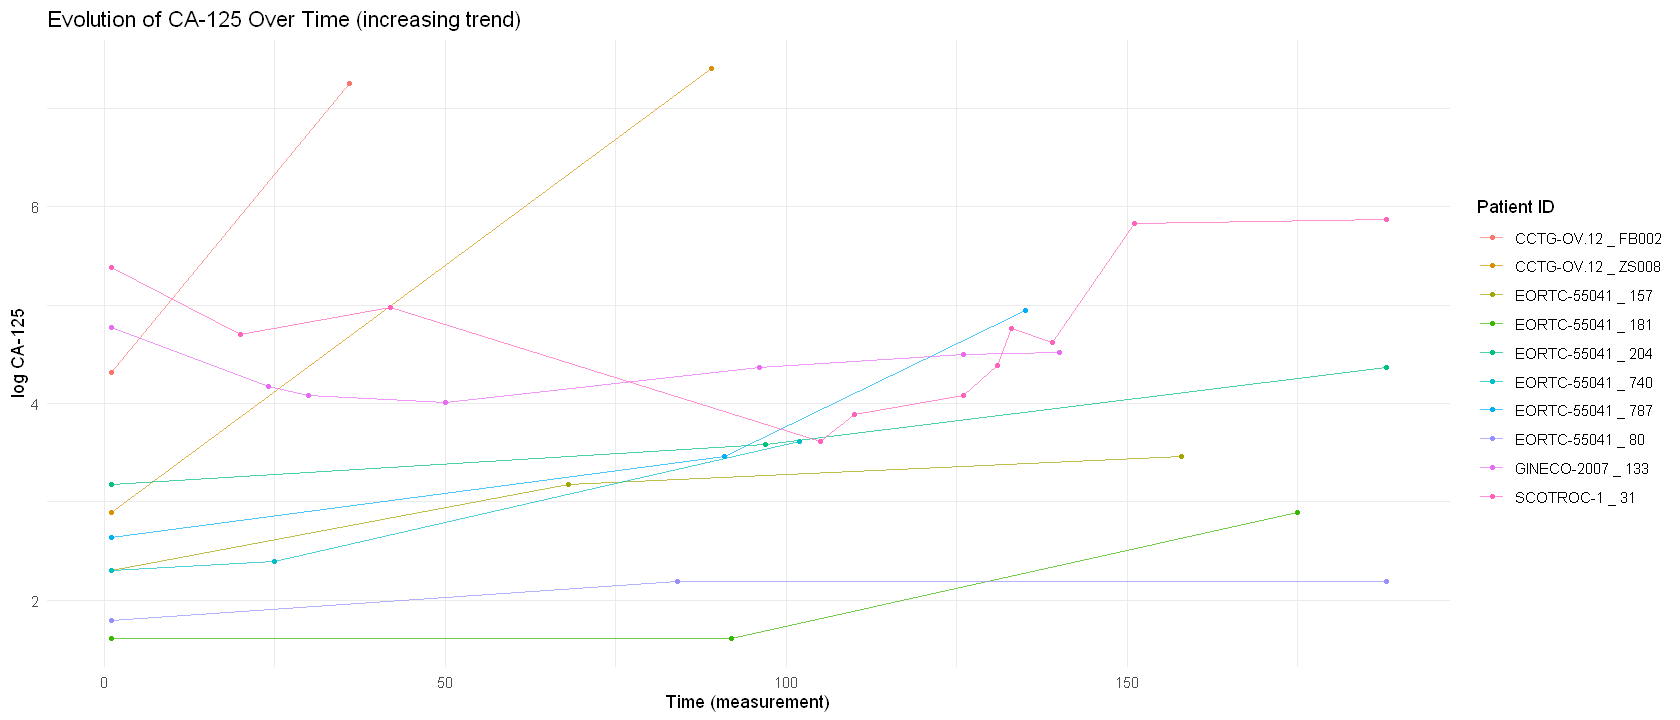

In [ ]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

**Summarise CA-125 values**

In [ ]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt) %>%
  
  summarise(
    
    n_measures = n(),
    n_patients = n_distinct(id),
    
    minca125 = min(CA125_mes, na.rm = TRUE),
    
    q1_ca125 = quantile(CA125_mes, 0.25, na.rm = TRUE),
    
    mean_ca125 = mean(CA125_mes, na.rm = TRUE),
    
    q3_ca125 = quantile(CA125_mes, 0.75, na.rm = TRUE),
    
    max_ca125 = max(CA125_mes, na.rm = TRUE),
        # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt)

trialid,trt,n_measures,n_patients,minca125,q1_ca125,mean_ca125,q3_ca125,max_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Investigational regimen,326,98,1.00,7.270,63.48276,27.675,3865.0,13.19018,56.74847,332.0001,265.9994
CCTG-OV.12,Standard regimen,322,96,0.60,7.000,129.15689,28.850,7027.0,21.11801,48.44720,327.9991,269.0005
CCTG-OV.16,Investigational regimen,2711,372,0.39,11.000,254.31692,128.000,12083.0,72.44559,85.06086,1457.9867,482.0083
CCTG-OV.16,Standard regimen,2806,359,0.21,11.000,191.45644,94.525,11800.0,71.66785,84.42623,1439.9981,524.0120
DoCaCel,Investigational regimen,16,8,7.00,9.000,126.43750,53.750,1046.0,62.50000,62.50000,791.0000,354.0000
DoCaCel,Standard regimen,24,11,9.00,11.000,226.25000,156.000,2100.0,79.16667,87.50000,1352.0000,374.5000
EORTC-55041,Investigational regimen,993,388,1.00,8.000,58.35952,23.000,3812.0,46.42497,76.33434,1340.0000,408.0000
EORTC-55041,Standard regimen,989,384,1.00,7.000,91.42568,23.000,14220.0,41.35490,72.49747,1372.0000,434.0000
GINECO-2007,Investigational regimen,292,48,4.00,16.000,253.08925,196.500,5180.0,86.98630,96.57534,1026.0000,490.0000


*Variables of interest per treatment group (should comparison tests? )* 

**Longitidunal model**

With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y$:
$
log[y(t_{ijk})]= f(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f(t)= (\theta_{1}+b_{1i}+b_{1ij}) + (\theta_{4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{k+2}+ b_{k+2,ij})B_{k+2}(t)+ (\theta_{5}+ b_{5,i})T_{ij}*t+ \sum_{k=0}^1 (\theta_{k+6}+ b_{k+6,i}) T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $(b_{1i}, b_{5i},b_{6i},b_{7i})^\top \sim N(0, \phi)$, $\phi = \begin{pmatrix} \sigma_{1}^2 & \sigma_1\sigma_5 &\sigma_1\sigma_6 & \sigma_1\sigma_7\\ \sigma_1\sigma_5 & \sigma_{5}^2 & \sigma_5\sigma_6 & \sigma_5\sigma_7\\ \sigma_1\sigma_6 & \sigma_5\sigma_6 & \sigma_{6}^2& \sigma_6\sigma_7 \\ \sigma_1\sigma_7 & \sigma_5\sigma_7 & \sigma_6\sigma_7 & \sigma_{7}^2 \end{pmatrix}$  (random effect at study level)
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_N)$


**Conditional BLUP for patient-level random effects**:

- $\theta=(\theta_1 \text{  } \theta_4 \text{  } \theta_2 \text{  } \theta_3 \text{  } \theta_5 \text{  } \theta_6 \text{  } \theta_7)^T$

Matricial form: $ y= X\theta + Z_sb_s + Z_{n}b_{n} + \epsilon$, with :
$
y =
\begin{pmatrix}
y(t_{111}) \\
y(t_{112}) \\
\vdots \\
y(t_{11 m_{11}}) \\
y(t_{121}) \\
\vdots \\
y(t_{1 n_1 m_{1m=n_1}}) \\
\vdots \\
y(t_{s n_s m_{sn_s}})
\end{pmatrix}
\in \mathbb{R}^{N},
\qquad
$,
$
X =
\begin{pmatrix}
1 & t_{111} & B_2(t_{111}) & B_3(t_{111}) & T_{11}*t_{111} & T_{11}*B_2(t_{111}) & T_{11}*B_3(t_{111}) \\
1 & t_{112} & B_2(t_{112}) & B_3(t_{112}) & T_{11}*t_{112} & T_{11}*B_2(t_{112}) & T_{11}*B_3(t_{112}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
1 & t_{11 m_{11}} & B_2(t_{11 m_{11}}) & B_3(t_{11 m_{11}}) & T_{11}*t_{11 m_{11}} & T_{11}*B_2(t_{11 m_{11}}) & T_{11}*B_3(t_{11 m_{11}}) \\
1 & t_{121} & B_2(t_{121}) & B_3(t_{121}) & T_{12}*t_{121} & T_{12}*B_2(t_{121}) & T_{12}*B_3(t_{121})\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{s n_s m_{sn_s}} & B_2(t_{s n_s m_{sn_s}}) & B_3(t_{s n_s m_{sn_s}}) & T_{sn_s}*t_{t_{s n_s m_{sn_s}}} & T_{sn_s}*B_2(t_{t_{s n_s m_{sn_s}}}) & T_{sn_s}*B_3(t_{t_{s n_s m_{sn_s}}})
\end{pmatrix}
\in \mathbb{R}^{N \times 7}
$
- $b_s \sim N(0, \Phi)$, $\Phi = \mathrm{diag}(\phi,...,\phi) \in \mathbb{R}^{6s \times 6s}$ (study-level random intercept)
$$
b_s =
\begin{pmatrix}
b_{11} & b_{51} &  b_{61}& b_{71} \\
b_{12} & b_{52} &  b_{62}& b_{72}  \\
\vdots & \vdots & \vdots & \vdots \\
b_{1s} & b_{5s} & b_{6s} &  b_{7s}
\end{pmatrix}
\in \mathbb{R}^{s \times 4}
$$
- $b_{n} \sim N(0, \Delta)$ (patient-level random intercept+slope), $
\Delta = \mathrm{diag}(D,...,D) \in \mathbb{R}^{5n \times 5n}
$

$$
b_{n} =
\begin{pmatrix}
b_{1,11} \\
b_{4,11} \\
b_{2,11} \\
b_{3,11} \\
b_{1,12} \\
b_{4,12} \\
b_{2,12} \\
b_{3,12} \\
\vdots \\
b_{1,s n_s} \\
b_{4,s n_s} \\
b_{2,s n_s}\\
b_{3,s n_s}
\end{pmatrix}
\in \mathbb{R}^{4n},
\qquad
$$

- $\epsilon \sim N(0, \sigma^2_{\epsilon}I_N)$

$\boxed{Var(y)=V=Z_s \Phi Z_s^T + Z_{n}\Delta Z_{n}^T + \sigma^2_{\epsilon}I_N}$\
with:
- $ Z_s =\begin{pmatrix}\mathbf{Z}_{s_1} & 0 & \cdots & 0 \\0 & \mathbf{Z}_{s_2} & \cdots & 0 \\\vdots & \vdots & \ddots & \vdots \\0 & 0 & \cdots & \mathbf{Z}_{s_s}\end{pmatrix} \in \mathbb{R}^{N \times 6s}$
. For trial $i$, $ Z_{s_i} =\begin{pmatrix}1 & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11})\\1 & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\\vdots & \vdots & \vdots\\1 & T_{in_i}*t_{in_im_i} & T_{in_i}*B_2(t_{in_im_i}) & T_{in_i}*B_3(t_{in_im_i}) \end{pmatrix}\in \mathbb{R}^{m_{i} \times 4}$

For patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n} = \Delta Z_{n}^\top V^{-1}(y-X\hat{\theta})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$


**BLUP for Study-Level Random Effect**\
$$
\widehat{b}_{s} = \Phi Z_s^\top V^{-1} (y-X\hat{\theta}) 
$$
$
\begin{pmatrix}
\hat b_{1i} \\
\hat b_{5i} \\
\hat b_{6i}\\
\hat b_{7j}
\end{pmatrix}
=[\Phi]_{i} \sum_{j=1}^{n_i} \sum_{k=1}^{m_{ij}}\begin{pmatrix}1 \\T_{ij}*t_{ijk} \\T_{ij}*B_2(t_{ijk}) \\T_{ij}*B_3(t_{ijk})\end{pmatrix}\,\bigl[V^{-1}(y - X\hat\theta)\bigr]_{ijk}
$



**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

In [ ]:
# internal_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.22, 0.66)))
# boundary_knots <- with(ca125_all_6,quantile(time_ca125, probs = c(0.18, 0.98)))
# ncs_trt_all <- lmer(
#   log(CA125_mes) ~ ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+ trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)+
#     (ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots) | id)+ (trt_bin:ns(time_ca125, knots =internal_knots, Boundary.knots = boundary_knots)|trialid),
#   data = ca125_all_6,
#   control = lmerControl(
#     optimizer = "bobyqa",
#     optCtrl = list(maxfun = 2e5)
#   )
# )
# attr(terms(ncs_trt_all), "predvars")
# saveRDS(ncs_trt_all, file = "./results/models/lmm.rds")


In [ ]:
ncs_trt_all <- readRDS(("./results/models/lmm.rds"))
summary(ncs_trt_all)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
log(CA125_mes) ~ ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    trt_bin:ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) +  
    (ns(time_ca125, knots = internal_knots, Boundary.knots = boundary_knots) |  
        id) + (trt_bin:ns(time_ca125, knots = internal_knots,  
    Boundary.knots = boundary_knots) | trialid)
   Data: ca125_all_6
Control: lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

REML criterion at convergence: 91240.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-15.0546  -0.3104  -0.0112   0.2826   9.8293 

Random effects:
 Groups  
 id      
         
         
         
 trialid 
         
         
         
         
         
         
 Residual
 Name                                                                             
 (Intercept)                                        

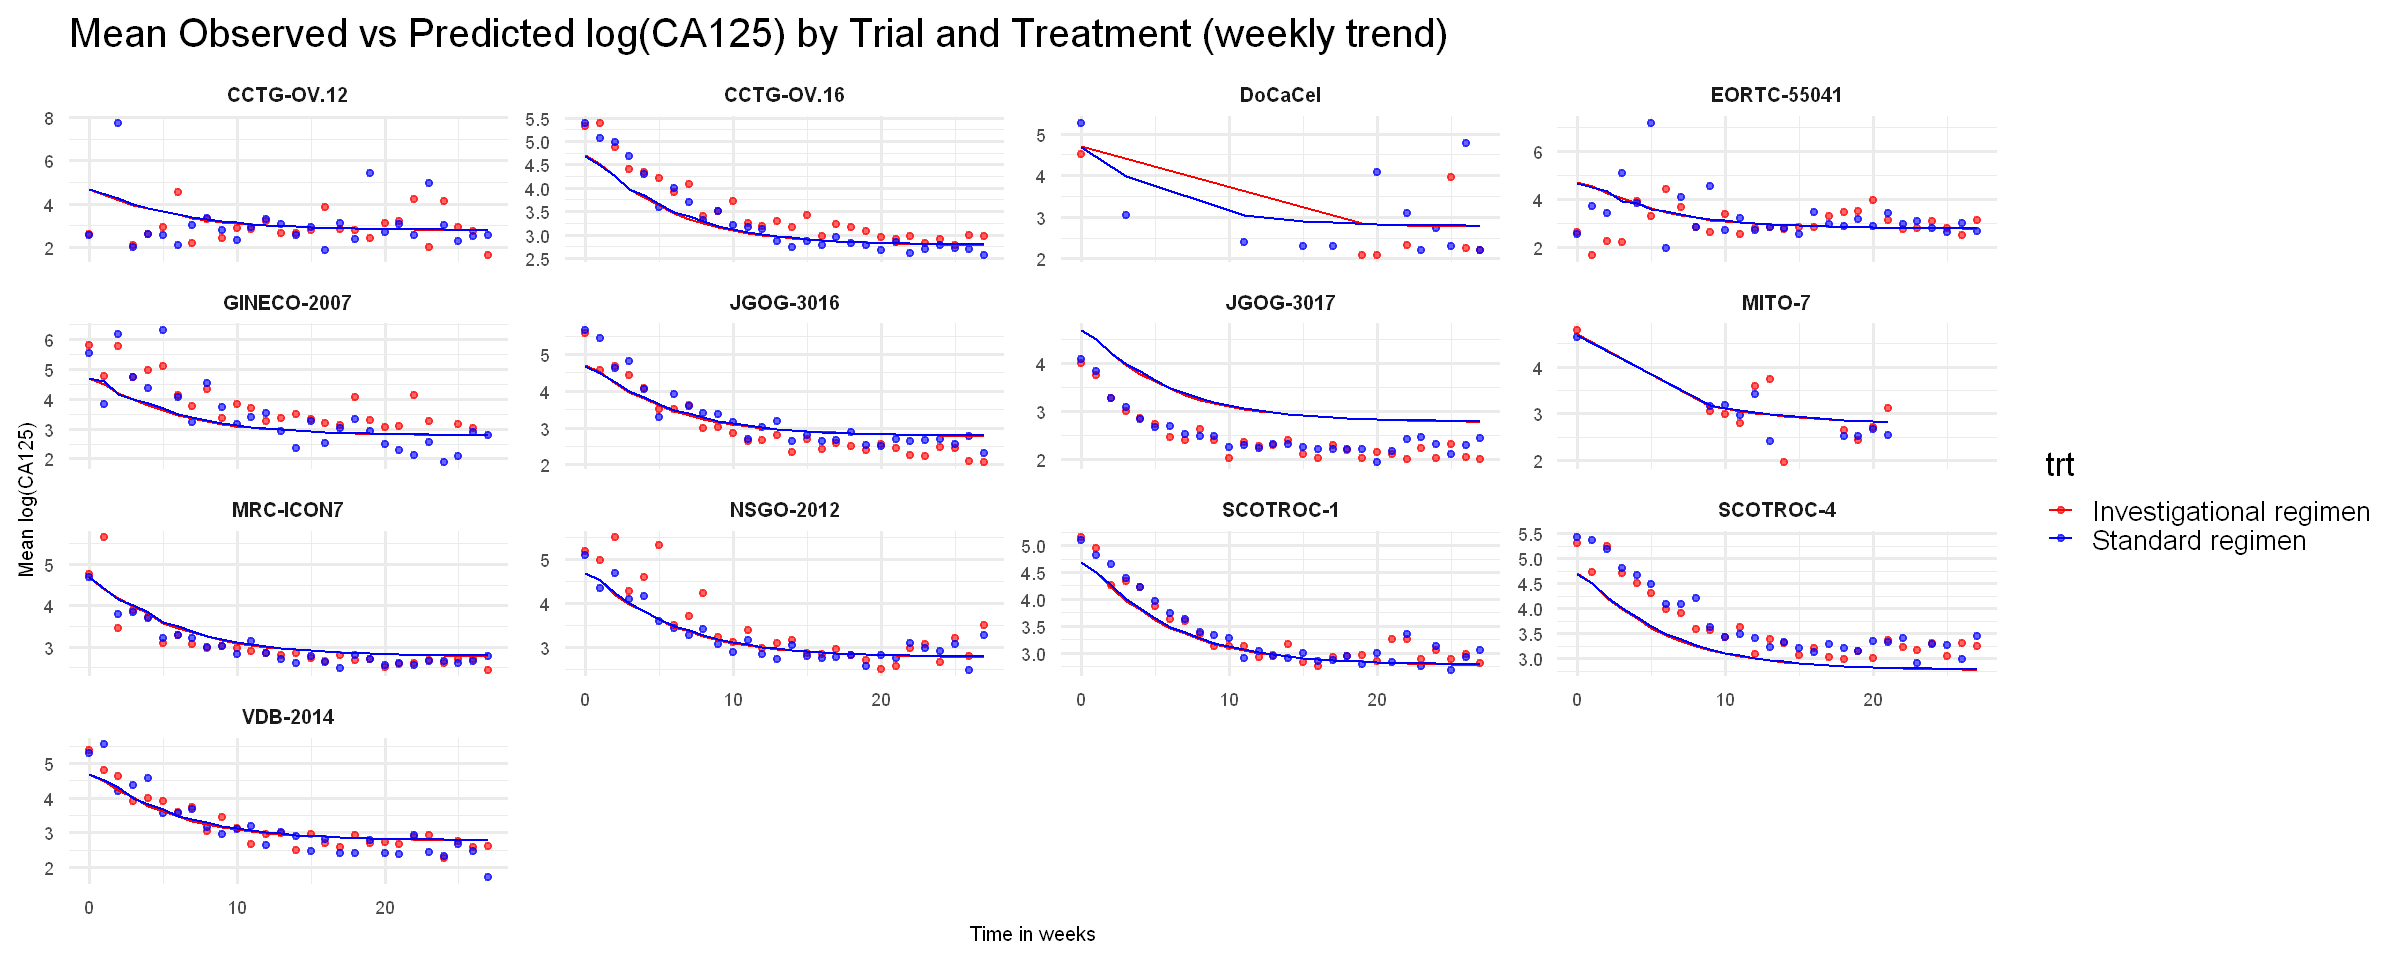

In [ ]:
# Comparison between real trajectories and predicited ones

options(repr.plot.width = 20, repr.plot.height = 8)
ca125_all_6 %>% mutate(week=round(time_ca125/7))%>%mutate(pred_all_13_nullbij= predict(
  ncs_trt_all,
  newdata = ca125_all_6,
  re.form =NA
))%>%
  group_by(trt, trialid, week) %>%
  summarise(
    mean_log_ca125 = mean(log(CA125_mes), na.rm = TRUE),
    mean_pred      = mean(pred_all_13_nullbij, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = mean_log_ca125),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = mean_pred),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

*Adéquation et tendance*

# Joint modeling

## Model

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

In [ ]:
internal_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.22,0.66))
boundary_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.18,0.98))
ns_basis <- ns(ca125_all_6$time_ca125,knots = internal_knots,Boundary.knots = boundary_knots)
ca125_all_6["id_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$id)))
ca125_all_6["trialid_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$trialid)))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [ ]:
# colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis)) 
# ca125_all_6 <- cbind(ca125_all_6, ns_basis)
# ca125_all_6$trt_ns1 <- ca125_all_6$trt_bin * ca125_all_6$ns1
# ca125_all_6$trt_ns2 <- ca125_all_6$trt_bin * ca125_all_6$ns2
# ca125_all_6$trt_ns3 <- ca125_all_6$trt_bin * ca125_all_6$ns3
# jointed_lcmm_pfs<-Jointlcmm(
#   fixed=log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + ns2 + ns3),
#   random=~ ns1 + ns2 + ns3,
#   subject="id_num",
#   ng = 1,
#   survival=Surv(pfs_time_d, pfs_statut) ~ trt_bin,
#   hazard = "splines",
#   data=ca125_all_6)
# saveRDS(jointed_lcmm_pfs, file = "./results/models/jointed_lcmm_pfs.rds")

In [ ]:
jointed_lcmm_pfs<-readRDS("./results/models/jointed_lcmm_pfs.rds")

In [ ]:
summary(jointed_lcmm_pfs)

Joint latent class model for quantitative outcome and competing risks 
     fitted by maximum likelihood method 
 
Jointlcmm(fixed = log_ca125 ~ ns1 + ns2 + ns3 + trt_bin:(ns1 + 
    ns2 + ns3), random = ~ns1 + ns2 + ns3, subject = "id_num", 
    ng = 1, survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin, 
    hazard = "splines", data = ca125_all_6)
 
Statistical Model: 
     Dataset: ca125_all_6 
     Number of subjects: 8140 
     Number of observations: 47463 
     Number of latent classes: 1 
     Number of parameters: 26  
     Event 1: 
        Number of events: 5544
        M-splines constant baseline risk function with nodes 
        0 289 508 980 5310.001  
 
Iteration process: 
     Convergence criteria satisfied 
     Number of iterations:  78 
     Convergence criteria: parameters= 1.3e-09 
                         : likelihood= 7.9e-06 
                         : second derivatives= 4.8e-06 
 
Goodness-of-fit statistics: 
     maximum log-likelihood: -90969.66  
     AIC: 1

In [ ]:
first_values <- ca125_all_6 %>% filter(trt_bin==0)%>%
  arrange(id_num, time_ca125) %>%   
  group_by(id_num) %>%
  slice(1) %>%                      # keep first record per patient
  ungroup()

mean(first_values$CA125_mes, na.rm = TRUE)

[1] 574.9648

* CI (Conditional independence) assuptiom (p-value=0) => longitudinal process and progression-time are not independent given random effects => CA125 itself carries additional information about progression, apart from patient-specific characteristics
* No treatment effect on progression-time
* Splines coeffs are significant => The risk of progression and evolution of CA125 vary nonlinearly over time
* High variances => patient-level heterogeneity in baseline CA125 and trajectory shape

In [ ]:
p<-WaldMult(jointed_lcmm_pfs, pos=c(13,14,15))
p

,Wald Test,p_value
ns1:trt_bin = ns2:trt_bin = ns3:trt_bin = 0,6.57139,0.08689


Non significant treatment effect across all splines

## Predictions

dynpred: “Given what I have observed as CA125 values for this patient up to time t, what is their survival probability going forward?”

# 🔹 Step-by-step mathematical idea behind dynamic prediction

## 1. Joint model specification

We consider a joint model with two linked components:

### Longitudinal model
$
Y_i(t) = X_i(t)\beta + Z_i(t) u_i + \epsilon_i(t)
$

- $ Y_i(t)$:  log CA125
- $ u_i $: subject-specific random effects
- $\epsilon_i(t)$: measurement error

### Survival model
$
\lambda_i(t \mid u_i) = \lambda_0(t)\exp\big(\gamma X_i + \alpha f(u_i, t)\big)
$

- $ \lambda_0(t)$: baseline hazard
- The hazard depends on the subject’s latent trajectory via $ u_i$

## 2. Unknown random effects

The random effects $ u_i $ are not observed.  
Instead, we estimate their posterior distribution using the observed longitudinal data up to time $ s $:

$
p(u_i \mid \text{data up to time } s)
$


## 3. Conditional survival given $ u_i $

If $ u_i $ were known, the survival function is:

$
S_i(t \mid u_i) = \exp\left(-\int_0^t \lambda_i(u \mid u_i)\, du \right)
$

The conditional probability of experiencing the event in the interval \([s, s+t]\) is:

$
P(T_i \le s+t \mid T_i > s, u_i)
= 1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
$


## 4. Marginal prediction (integrating over $ u_i $)

Since $ u_i $ is unknown, we integrate over its posterior distribution:

$
P(T_i \le s+t \mid \text{data}) =
\int \left[
1 - \frac{S_i(s+t \mid u_i)}{S_i(s \mid u_i)}
\right]
p(u_i \mid \text{data up to } s)\, du_i
$


## 5. Monte Carlo approximation

This integral is approximated numerically:

1. Draw samples:
$
u_i^{(1)}, \dots, u_i^{(M)} \sim p(u_i \mid \text{data})
$

2. Compute for each draw:
$
p^{(m)} = 1 - \frac{S_i(s+t \mid u_i^{(m)})}{S_i(s \mid u_i^{(m)})}
$

3. Summarize:
- Median → predicted probability
- 2.5% and 97.5% → confidence interval


## 6. Interpretation

This gives a **dynamic prediction**:

$
P(T_i \le s+t \mid T_i > s,\ \text{history up to } s)
$

That is, the probability that subject $ i $ experiences the event in the next $ t $ time units, given:
- they are event-free at time $ s $
- their observed biomarker trajectory up to time $ s $

In [ ]:
# pred <- dynpred(
#   model = jointed_lcmm_pfs,
#   newdata = ca125_all_6,
#   event = 1,
#   landmark = c(7, 30, 90),
#   horizon = c(7, 14),
#   var.time = "time_ca125",
#   draws = TRUE,
#   ndraws = 150
# )
# dynpreds<-saveRDS(pred, file = "pred_dynpred.rds")

In [ ]:
dynpreds<-readRDS("./results/models/pred_dynpred.rds")

In [ ]:
# Evaluation of prediction of progression at 2, 3 and 5 years
# horizons:
# 550  = ~2 years
# 915  = ~3 years
# 1645 = ~5 years

# function for manual AUC
auc_manual <- function(labels, scores) {
  roc_obj <- pROC::roc(labels, scores, quiet = TRUE)
  as.numeric(pROC::auc(roc_obj))
}

# evaluation for each horizon
eval_df <- map_dfr(
  c(550, 915, 1645),
  function(h) {
    
    # convert horizon to years for observed event definition
    years <- case_when(
      h == 550  ~ 2,
      h == 915  ~ 3,
      h == 1645 ~ 5
    )
    
    obs <- dynpreds[[1]] %>%
      filter(horizon == h) %>%
      select(id_num, pred) %>%
      left_join(
        ca125_all_6 %>%
          select(id_num, pfs_time_d, pfs_statut) %>%
          distinct(),
        by = "id_num"
      ) %>%
      mutate(
        event = ifelse(pfs_time_d <= years * 365 & pfs_statut == 1, 1, 0),
        pred_class = as.numeric(pred >= 0.5)
      )
    
    obs %>%
      summarise(
        years = years,
        
        accuracy =
          mean(pred_class == event, na.rm = TRUE),
        
        sensitivity =
          sum(pred_class == 1 & event == 1, na.rm = TRUE) /
          sum(event == 1, na.rm = TRUE),
        
        specificity =
          sum(pred_class == 0 & event == 0, na.rm = TRUE) /
          sum(event == 0, na.rm = TRUE),
        
        auc =
          auc_manual(event, pred),
        
        n_events =
          sum(event, na.rm = TRUE),
        
        n_patients =
          n()
      )
  }
)

eval_df

years,accuracy,sensitivity,specificity,auc,n_events,n_patients
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2,0.4390554,0.0000000,0.9172821,0.5070629,4548,8140
3,0.6268382,0.8774743,0.0000000,0.5068975,5052,8140
5,0.6638857,0.8798726,0.0000000,0.5108831,5336,8140


*Goodness of fit of joint model*

## Link between risk ratio and CA125

In [ ]:
kelim <- read.csv("./data/data_GCIG_KELIM.csv", sep=";")
kelim <- kelim%>%mutate(id=paste(trial_name,"_",patid))%>%
                 mutate(trt_bin=as.factor(if_else(ttt_arm=="ctrl", 0,1))) %>%
                 select(id,trial_name,trt_bin, KELIM_continuous,KELIM_score)
print(paste0(c("Number of patients:", nrow(kelim))))
print(paste0(c("Number of trials:", length(unique(kelim$trial_name)))))

[1] "Number of patients:" "5884"               
[1] "Number of trials:" "8"                


**One joint model per trial**

In [ ]:
# ca125_all_6<-ca125_all_6 %>%arrange(id_num)
# trial_list <- split(ca125_all_6, ca125_all_6$trialid)
# # -----------------------------
# # storage
# # -----------------------------

# results_list <- list()
# weekly_predictions<-list()
# average_values<-list()
# model_store <- list()
# nadirs<-list()
# nadirs_week<-list()
# wald_list <-list()

# # -----------------------------
# # loop
# # -----------------------------

# for (trial_name in names(trial_list)) {

#   cat("Fitting:", trial_name, "\n")

#   df <- trial_list[[trial_name]]

#   # -------------------------
#   # spline basis
#   # -------------------------
#   internal_knots <- quantile(df$time_ca125, c(0.22, 0.66))
#   boundary_knots <- quantile(df$time_ca125, c(0.18, 0.98))

#   ns_basis <- ns(df$time_ca125,
#                  knots = internal_knots,
#                  Boundary.knots = boundary_knots)

#   colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis))
#   df <- cbind(df, ns_basis)
#   df$week <- round(df$time_ca125/7)

#   # -------------------------
#   # model
#   # -------------------------
#   model <- tryCatch({

#     Jointlcmm(
#       fixed = log_ca125 ~ ns1 + ns2 + ns3 +
#         trt_bin:(ns1 + ns2 + ns3),
#       random = ~ ns1 + ns2 + ns3,
#       subject = "id_num",
#       ng = 1,
#       survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
#       hazard = "splines",
#       data = df,
#       maxiter = 1500
#     )
  
#   }, error = function(e) NULL)

#   if (is.null(model)) next
#   model_coefs<-model$best
#   log_ca125_pred <- predictY(model,newdata = df,var.time = "time_ca125")$pred
#   weekly_prediction <- tryCatch({
#     ca125_patient <- data.frame(trialid = trial_name,
#                                 trt=df$trt_bin,
#                                 log_ca125=as.vector(df$log_ca125),
#                                 week=df$week, 
#                                 log_ca125_pred =as.vector(log_ca125_pred)) %>%
#       group_by(trialid, trt, week) %>%
#       summarise(
#         log_ca125_pred_week =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         log_ca125_week =
#           mean(
#             log_ca125,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       )
    
#   }, error = function(e) {
    
#     cat(
#       "❌ Failed:",
#       trial_name,
#       "\n"
#     )
    
#     print(e$message)
    
#     NULL
#   })

#   average_value <- tryCatch({
#     ca125_patient <- data.frame(id_num = df$id_num,log_ca125_pred =as.vector(log_ca125_pred)) %>%
#       group_by(id_num) %>%
#       summarise(
#         log_ca125_pred =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       )
    
#     # -------------------------
#     # Number of events
#     # -------------------------
#     n_events_trial <- df %>%
#       distinct(
#         id_num,
#         .keep_all = TRUE
#       ) %>%
#       summarise(
#         n_events =
#           sum(
#             pfs_statut == 1,
#             na.rm = TRUE
#           )
#       ) %>%
#       pull(n_events)
    
#     # -------------------------
#     # Trial summary
#     # -------------------------
#     trial_summary <- ca125_patient %>%
#       summarise(
#         mean_log_ca125 =
#           mean(
#             log_ca125_pred,
#             na.rm = TRUE
#           ),
#         .groups = "drop"
#       ) %>%
#       mutate(
#         trialid = trial_name,
#         log_hr = model_coefs["trt_bin1"][1],
#         hr = exp(model_coefs["trt_bin1"][1]),
#         n_events = n_events_trial
#       )
    
#     trial_summary
    
#   }, error = function(e) {
    
#     cat(
#       "❌ Failed:",
#       trial_name,
#       "\n"
#     )
    
#     print(e$message)
    
#     NULL
#   })
  
  
#   weekly_predictions[[trial_name]] <- weekly_prediction
#   model_store[[trial_name]] <- model
#   average_values[[trial_name]] <- average_value
#   wald_list[[trial_name]] <-WaldMult(model, pos=c(13,14,15))
#   beta_longitudinal_trt <- model_coefs[grep("ns[1-3]:trt_bin1", names(model_coefs))]

#   # -------------------------
#   # prediction grid
#   # -------------------------
#   time_grid <- seq(min(df$time_ca125),
#                    max(df$time_ca125),
#                    length.out = 200)

#   pred_ctrl <- data.frame(time_ca125 = time_grid, trt_bin = 0)
#   pred_trt  <- data.frame(time_ca125 = time_grid, trt_bin = 1)

#   ns_ctrl <- predict(ns(df$time_ca125,
#                         knots = internal_knots,
#                         Boundary.knots = boundary_knots),
#                      newx = time_grid)

#   colnames(ns_ctrl) <- c("ns1","ns2","ns3")

#   pred_ctrl <- cbind(pred_ctrl, ns_ctrl)
#   pred_trt  <- cbind(pred_trt, ns_ctrl)

#   # -------------------------
#   # predictions
#   # -------------------------
#   y_ctrl <- predictY(model, newdata = pred_ctrl, var.time = "time_ca125")
#   y_trt  <- predictY(model, newdata = pred_trt,  var.time = "time_ca125")

#   # -------------------------
#   # NADIR
#   # -------------------------
#   nadir_ctrl <- min(y_ctrl$pred[,1], na.rm=TRUE)
#   nadir_trt  <- min(y_trt$pred[,1], na.rm=TRUE)
#   delta_nadir <- nadir_trt - nadir_ctrl
#   nadirs[[trial_name]]<-data.frame(nadir_trt=nadir_trt,nadir_ctrl=nadir_ctrl)

#   # -------------------------
#   # weekly NADIR
#   # -------------------------
#   weekly_ctrl <- get_weekly_nadir(time_grid, y_ctrl$pred, week_size = 7)
#   weekly_trt  <- get_weekly_nadir(time_grid, y_trt$pred,  week_size = 7)

#   # global nadir (from weekly values)

#   nadirs_week[[trial_name]] <- data.frame(
#     nadir_trt = min(weekly_trt$x, na.rm = TRUE),
#     nadir_ctrl = min(weekly_ctrl$x, na.rm = TRUE)
#   )
#   # -------------------------
#   # time-to-nadir
#   # -------------------------
#   t_nadir_ctrl <- time_grid[which.min(y_ctrl$pred[,1])]
#   t_nadir_trt  <- time_grid[which.min(y_trt$pred[,1])]
#   delta_t_nadir <- t_nadir_trt - t_nadir_ctrl

#   # -------------------------
#   # AUC
#   # -------------------------
#   auc_ctrl <- compute_auc(y_ctrl, time_grid)
#   auc_trt  <- compute_auc(y_trt, time_grid)
#   delta_auc <- auc_trt - auc_ctrl

#   # -------------------------
#   # percent reduction
#   # -------------------------
#   delta_pcts <- get_monthly_pct_reduction(
#   time_grid,
#   y_ctrl,
#   y_trt,
#   months = 1:6)

#   # -------------------------
#   # 6-month slopes
#   # -------------------------
#   delta_slopes <- get_monthly_slopes(time_grid, y_ctrl, y_trt)

#   # -------------------------
#   # Absolute differences
#   # -------------------------

#   #1 month
#   idx_30  <- which.min(abs(time_grid - 30))
#   D_30 <- y_trt$pred[idx_30, 1] - y_ctrl$pred[idx_30, 1]
#   #2 months
#   idx_60  <- which.min(abs(time_grid - 60))
#   D_60 <- y_trt$pred[idx_60, 1] - y_ctrl$pred[idx_60, 1]
#   #3 months
#   idx_90  <- which.min(abs(time_grid - 90))
#   D_90 <- y_trt$pred[idx_90, 1] - y_ctrl$pred[idx_90, 1]
#   #4 months
#   idx_120  <- which.min(abs(time_grid - 120))
#   D_120 <- y_trt$pred[idx_120, 1] - y_ctrl$pred[idx_120, 1]
#   #5 months
#   idx_150  <- which.min(abs(time_grid - 150))
#   D_150 <- y_trt$pred[idx_150, 1] - y_ctrl$pred[idx_150, 1]
#   #6 months
#   idx_180 <- which.min(abs(time_grid - 180))
#   D_180 <- y_trt$pred[idx_180, 1] - y_ctrl$pred[idx_180, 1]

#   #Effect of treatment on Kelim:
#   kelim_data<- kelim[kelim$trial_name==trial_name,]
#   if (nrow(kelim_data)>0){
#     linear_reg<-lm(KELIM_continuous ~ trt_bin, data = kelim_data)
#     beta_kelim<-linear_reg$coefficients["trt_bin1"]
#     delta_kelim<-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==1], na.rm=TRUE)-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==0], na.rm=TRUE)
#   }else{
#     beta_kelim<-NA
#     delta_kelim<-NA
#   }


#   # -------------------------
#   # store
#   # -------------------------
#   results_list[[trial_name]] <- data.frame(
#     trialid = trial_name,
#     logHR = model_coefs["trt_bin1"] ,
#     SE_logHR = sqrt(diag(vcov(model)))["trt_bin1"],
#     effect_trt_ca1251 = beta_longitudinal_trt[1],
#     effect_trt_ca1252 = beta_longitudinal_trt[2],
#     effect_trt_ca1253 = beta_longitudinal_trt[3],
#     beta_kelim = beta_kelim,
#     delta_kelim = delta_kelim,

#     delta_nadir = delta_nadir,
#     delta_time_nadir = delta_t_nadir,
#     delta_auc = delta_auc,
    
#     pct_m1 = delta_pcts[1],
#     pct_m2 = delta_pcts[2],
#     pct_m3 = delta_pcts[3],
#     pct_m4 = delta_pcts[4],
#     pct_m5 = delta_pcts[5],
#     pct_m6 = delta_pcts[6],

#     absolutediff_m1=D_30,
#     absolutediff_m2=D_60,
#     absolutediff_m3=D_90,
#     absolutediff_m4=D_120,
#     absolutediff_m6=D_150,
#     absolutediff_m5=D_180,

#     slope_m1 = delta_slopes[1],
#     slope_m2 = delta_slopes[2],
#     slope_m3 = delta_slopes[3],
#     slope_m4 = delta_slopes[4],
#     slope_m5 = delta_slopes[5],
#     slope_m6 = delta_slopes[6],

#     n=nrow(df),
#     n_events = nrow(df%>%filter(pfs_statut==1)%>% distinct(id))
#   )
# }

# #Save results
# save(wald_list, file = "results/summaries/wald_list.RData")
# save(results_list, file = "results/summaries/results_list.RData")
# save(weekly_predictions, file = "results/summaries/weekly_predictions.RData")
# save(average_values, file = "results/summaries/average_values.RData")



In [ ]:
wald_list<-get(load("results/summaries/wald_list.RData"))
weekly_predictions<-get(load("results/summaries/weekly_predictions.RData"))
average_values<-get(load("results/summaries/average_values.RData"))
results_list<-get(load("results/summaries/results_list.RData"))

trial_results <- bind_rows(results_list)
trial_weekly_predictions <- bind_rows(weekly_predictions)
trial_summary <- bind_rows(average_values)

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead."
`geom_smooth()` using formula = 'y ~ x'
Warning message:
"The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"


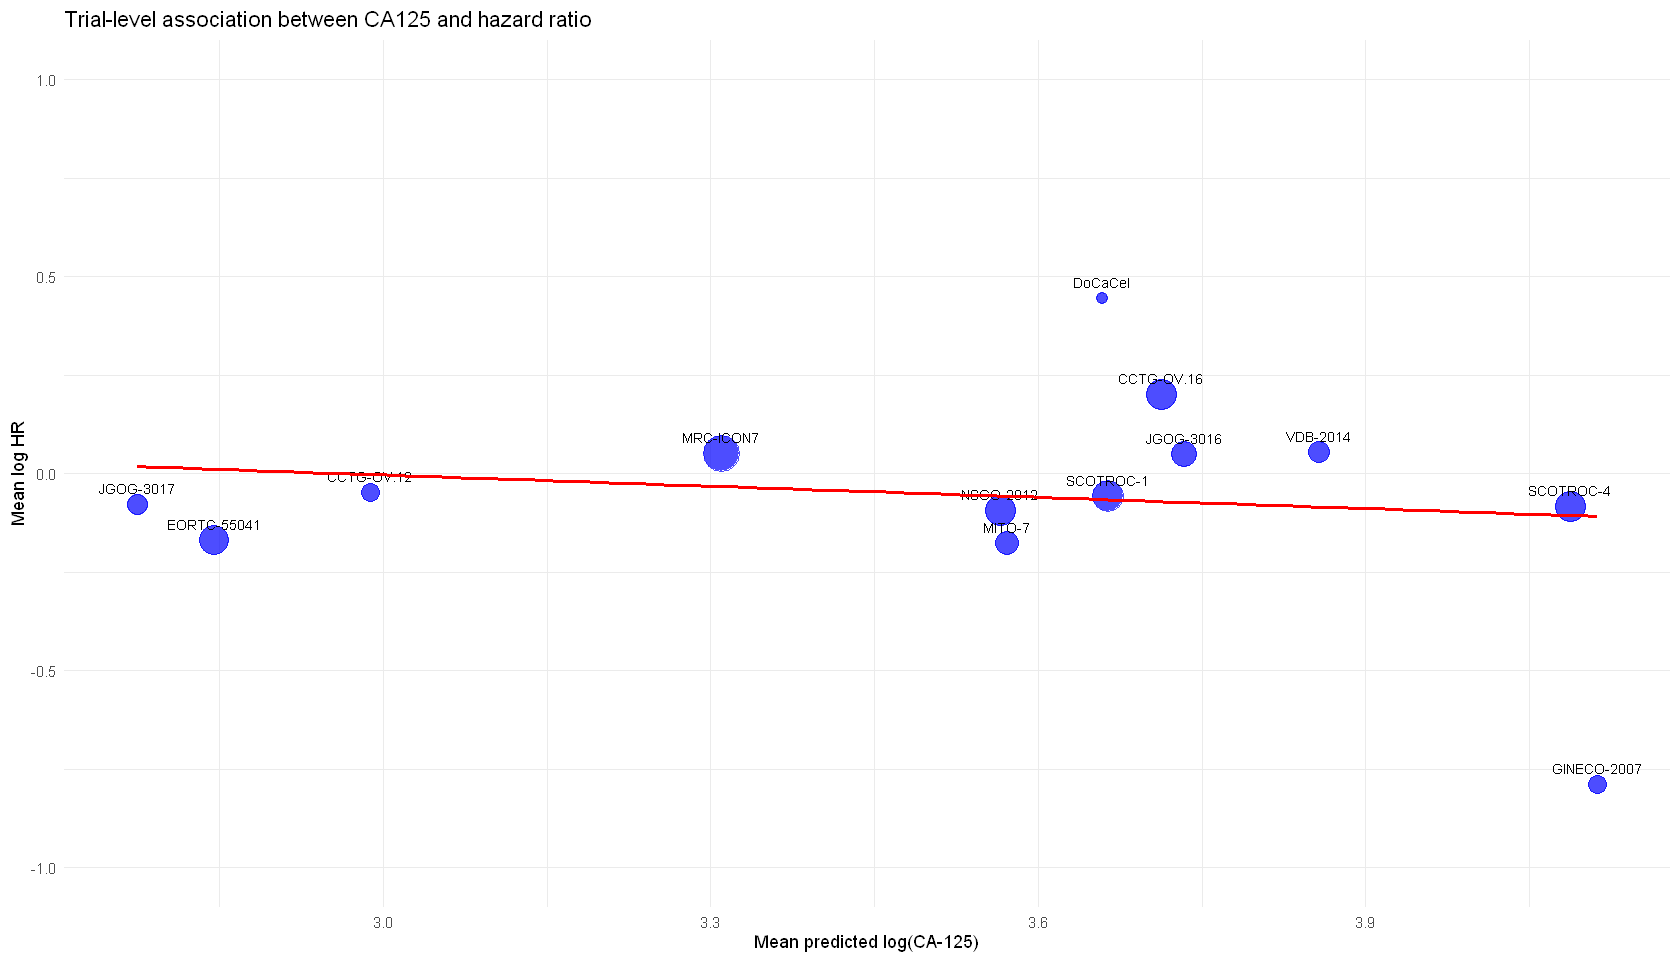

In [ ]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary,
       aes(x = mean_log_ca125,
           y = log_hr,
           size = n_events)) +
  geom_point(color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "Mean log HR",
    title = "Trial-level association between CA125 and hazard ratio"
  ) +
  ylim(-1, 1)

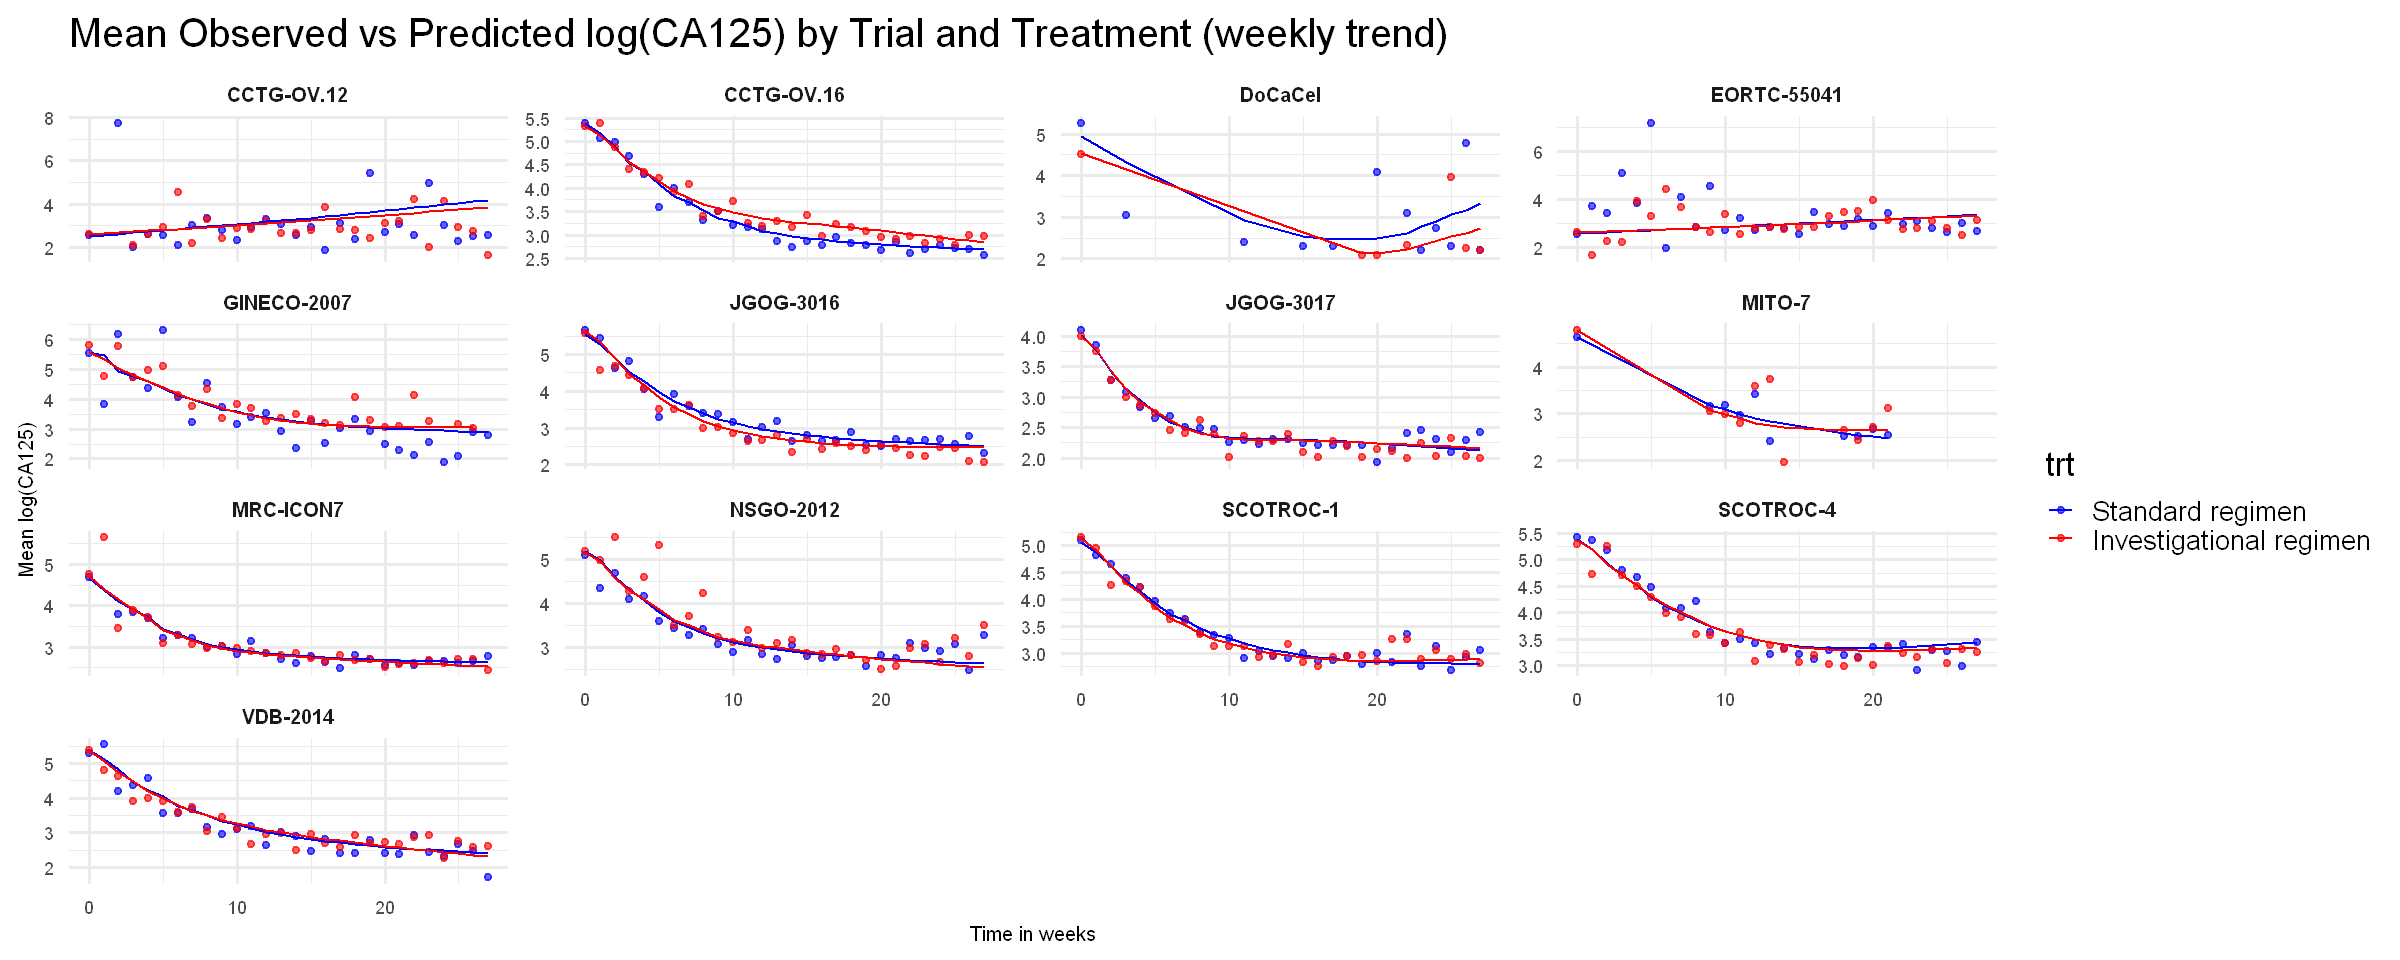

In [ ]:
# Comparison between real trajectories and predicited ones
options(repr.plot.width = 20, repr.plot.height = 8)
trial_weekly_predictions %>%
  mutate(trt = factor(trt, levels = c(0, 1),
                        labels = c("Standard regimen", "Investigational regimen")))%>% 
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = log_ca125_week),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = log_ca125_pred_week),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

**Compute $R^2_{trial}$**
- One joint model by trial then extract log(HR) associated with "trt_bin"
- Predict average log(CA-125) trajectory for treatment group and control group using joint model\
1) **Nadir:** $\Delta = min_t(\hat{Y}_{trt}) - min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta$ 
2) **Time to nadir:** $\Delta_t = \text{time to }min_t(\hat{Y}_{trt}) - \text{time to }min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta_t$
3) **Difference of slopes:** $S_i=\frac{\hat{Y}(t_i) -\hat{Y}(t_i-1)}{t_i - t_i-1}$, $i \in \{30,60,90,120,150,180\}$, $log(HR) = \alpha + \beta (S_{i_{trt}}- S_{i_{ctrl}})$
4) **Area between curves:** $AUC\approx \sum_{i=1}^{n-1} (t_{i+1} - t_i)\,\frac{(\hat{Y_{trt}}(t_i) -\hat{Y_{ctrl}}(t_i) )+ (\hat{Y}_{trt}(t_{i+1}) -\hat{Y}_{ctrl}(t_{i+1}))}{2}$, $log (HR)= \alpha + \beta AUC$
5) **Reduction from baseline:** $R=\frac{\hat{Y}(t_0) - \hat{y}(t_f)}{\hat{Y}(t_0)}$, $\Delta R = R_{trt} - R_{ctrl}$, $log (HR)= \alpha + \beta \Delta R$ (refaire à tous les mois)
6) **Methode henderson:** $logHR= \alpha + \beta T$, T=vecteur effet traitement sur surrogate
7) $log(HR)= \alpha +\beta D_i$,  $D_i=\hat{Y}(t_i)_{trt} - \hat{Y}(t_i)_{ctrl}$, $t_i \in \{60,180\}$




In [ ]:
wald_list

ERROR: Error: objet 'wald_list' introuvable


In [ ]:

summary_models <- list(
      nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = n_events),
      time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = n_events),
      auc = lm(logHR ~ delta_auc, data = trial_results, weights = n_events),
      beta_kelim = lm(logHR ~ beta_kelim, data = trial_results, weights = n_events),
      delta_kelim = lm(logHR ~ delta_kelim, data = trial_results, weights = n_events),
      pct1 = lm(logHR ~ pct_m1, data = trial_results, weights = n_events),
      pct2= lm(logHR ~ pct_m2, data = trial_results, weights = n_events),
      pct3= lm(logHR ~ pct_m3, data = trial_results, weights = n_events),
      pct4= lm(logHR ~ pct_m4, data = trial_results, weights = n_events),
      pct5= lm(logHR ~ pct_m5, data = trial_results, weights = n_events),
      pct6= lm(logHR ~ pct_m6, data = trial_results, weights = n_events),
      henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = n_events),
      slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = n_events),
      slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = n_events),
      slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = n_events),
      slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = n_events),
      slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = n_events),
      slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = n_events),
      abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = n_events),
      abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = n_events),
      abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = n_events),
      abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = n_events),
      abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = n_events),
      abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = n_events))
# -----------------------------
# extract R2 table
# -----------------------------
r2_table <- data.frame(
  model = names(summary_models),

  R2 = sapply(summary_models, function(m) summary(m)$r.squared),

  coeff = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Estimate"]
  })),

  pval = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Pr(>|t|)"]
  }))
)

In [ ]:
r2_table

,model,R2,coeff,pval
,<chr>,<dbl>,<I<named list>>,<I<named list>>
nadir,nadir,0.0234425550,-0.03173....,0.501291....
time_nadir,time_nadir,0.0590736508,-0.02093....,0.663744....
auc,auc,0.0739855418,-0.03253....,0.479259....
beta_kelim,beta_kelim,0.0201391731,-0.01419....,0.832389....
delta_kelim,delta_kelim,0.0201391731,-0.01419....,0.832389....
pct1,pct1,0.0075034519,-0.02665....,0.605474....
pct2,pct2,0.0788054984,-0.01935....,0.683909....
pct3,pct3,0.1703747642,-0.02195....,0.616565....
pct4,pct4,0.1602744086,-0.02558....,0.559946....


In [ ]:
# #Weigthing by 1/var:
# summary_models2 <- list(
#       nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
#       time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
#       auc = lm(logHR ~ delta_auc, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct1 = lm(logHR ~ pct_m1, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct2= lm(logHR ~ pct_m2, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct3= lm(logHR ~ pct_m3, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct4= lm(logHR ~ pct_m4, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct5= lm(logHR ~ pct_m5, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct6= lm(logHR ~ pct_m6, data = trial_results, weights = 1/(SE_logHR**2)),
#       henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = 1/(SE_logHR**2)))
# # -----------------------------
# # extract R2 table
# # -----------------------------
# r2_table2 <- data.frame(
#   model = names(summary_models2),

#   R2 = sapply(summary_models2, function(m) summary(m)$r.squared),

#   coeff = I(lapply(summary_models2, function(m) {
#     summary(m)$coefficients[, "Estimate"]
#   })),

#   pval = I(lapply(summary_models2, function(m) {
#     summary(m)$coefficients[, "Pr(>|t|)"]
#   }))
# )

In [ ]:
# cbind(r2_table[c("model","R2")],r2_table2["R2"])

In [ ]:
#Boostrap for r2 CI
set.seed(123)

B <- 2000
n <- nrow(trial_results)

boot_r2 <- matrix(NA, nrow = B, ncol = 23)
colnames(boot_r2) <- c("nadir","time_nadir","auc","beta_kelim", "delta_kelim","pct1","pct2","pct3", "pct4", "pct5","pct6",
                       "slope1","slope2","slope3","slope4", "slope5","slope6",
                       "abs1","abs2","abs3","abs4","abs5","abs6")

for (b in 1:B) {

  idx <- sample(1:n, size = n, replace = TRUE)
  data_b <- trial_results[idx, ]

  boot_r2[b, ] <- get_r2_models(data=data_b)
}
boot_summary <- data.frame(
  model = colnames(boot_r2),

  R2 = apply(boot_r2, 2, mean, na.rm = TRUE),

  R2_low = apply(boot_r2, 2, quantile, 0.025, na.rm = TRUE),

  R2_high = apply(boot_r2, 2, quantile, 0.975, na.rm = TRUE)
)

boot_summary

Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(m):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


,model,R2,R2_low,R2_high
,<chr>,<dbl>,<dbl>,<dbl>
nadir,nadir,0.2092325,1.697349e-04,0.7153248
time_nadir,time_nadir,0.1592657,7.731062e-05,0.7200472
auc,auc,0.2534274,1.814676e-02,0.6326706
beta_kelim,beta_kelim,0.2077612,1.004146e-04,0.8942028
delta_kelim,delta_kelim,0.2077612,1.004146e-04,0.8942028
pct1,pct1,0.1238089,2.274884e-04,0.4910719
pct2,pct2,0.1677658,1.110347e-03,0.6123117
pct3,pct3,0.2232686,4.904121e-04,0.6766400
pct4,pct4,0.2185191,9.854077e-04,0.6524277


In [ ]:
ca125_all_6 %>%mutate(week_ca125=round(time_ca125/7))%>%
  group_by(trialid, trt, week_ca125) %>%
  summarise(mean_ca125 = mean(log_ca125, na.rm = TRUE), .groups = "drop") %>%
  group_by(trialid, trt) %>%
  summarise(min_mean_ca125 = min(mean_ca125, na.rm = TRUE))

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by trialid and trt.
ℹ Output is grouped by trialid.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(trialid, trt))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


trialid,trt,min_mean_ca125
<chr>,<chr>,<dbl>
CCTG-OV.12,Investigational regimen,1.609438
CCTG-OV.12,Standard regimen,1.844461
CCTG-OV.16,Investigational regimen,2.769822
CCTG-OV.16,Standard regimen,2.560898
DoCaCel,Investigational regimen,2.079442
DoCaCel,Standard regimen,2.197225
EORTC-55041,Investigational regimen,1.666102
EORTC-55041,Standard regimen,1.962035
GINECO-2007,Investigational regimen,3.003475


In [ ]:
bind_rows(nadirs_week)

nadir_trt,nadir_ctrl
<dbl>,<dbl>
2.599490,2.512384
2.840088,2.689550
2.122120,2.452159
2.613962,2.573492
3.063969,2.883312
2.456991,2.503884
2.162278,2.123354
2.630669,2.463167
2.523464,2.619287


Leave-one-trial-out

In [ ]:
# ----------------------------------
# formulas for all summary models
# ----------------------------------

summary_formulas <- list(
  nadir = logHR ~ delta_nadir,
  time_nadir = logHR ~ delta_time_nadir,
  auc = logHR ~ delta_auc,
  beta_kelim = logHR ~ beta_kelim,
  delta_kelim = logHR ~ delta_kelim,

  pct1 = logHR ~ pct_m1,
  pct2 = logHR ~ pct_m2,
  pct3 = logHR ~ pct_m3,
  pct4 = logHR ~ pct_m4,
  pct5 = logHR ~ pct_m5,
  pct6 = logHR ~ pct_m6,

  henderson = logHR ~ effect_trt_ca1251 +
                      effect_trt_ca1252 +
                      effect_trt_ca1253,

  slope1 = logHR ~ slope_m1,
  slope2 = logHR ~ slope_m2,
  slope3 = logHR ~ slope_m3,
  slope4 = logHR ~ slope_m4,
  slope5 = logHR ~ slope_m5,
  slope6 = logHR ~ slope_m6,

  abs1 = logHR ~ absolutediff_m1,
  abs2 = logHR ~ absolutediff_m2,
  abs3 = logHR ~ absolutediff_m3,
  abs4 = logHR ~ absolutediff_m4,
  abs5 = logHR ~ absolutediff_m5,
  abs6 = logHR ~ absolutediff_m6
)

# ----------------------------------
# leave-one-study-out
# ----------------------------------

B <- 1000

loso_boot_results <- list()

for(trial_out in unique(trial_results$trialid)) {

  cat("Leaving out:", trial_out, "\n")

  df_loso <- subset(
    trial_results,
    trialid != trial_out
  )

  model_results <- lapply(names(summary_formulas), function(model_name){

    r2_boot <- replicate(B, {

      idx <- sample(
        seq_len(nrow(df_loso)),
        size = nrow(df_loso),
        replace = TRUE
      )

      boot_df <- df_loso[idx, ]

      fit <- lm(
        summary_formulas[[model_name]],
        data = boot_df,
        weights = n
      )

      summary(fit)$r.squared
    })

    data.frame(
      left_out_trial = trial_out,
      summary = model_name,
      R2 = mean(r2_boot),
      CI_low = quantile(r2_boot, 0.025),
      CI_high = quantile(r2_boot, 0.975)
    )
  })

  loso_boot_results[[trial_out]] <- bind_rows(model_results)
}

loso_boot_r2 <- bind_rows(loso_boot_results)

Leaving out: CCTG-OV.12 


Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


Leaving out: CCTG-OV.16 


Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


Leaving out: DoCaCel 
Leaving out: EORTC-55041 


...

Leaving out: SCOTROC-1 


Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


Leaving out: SCOTROC-4 


Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"
Warning message in summary.lm(fit):
"ajustement pratiquement parfait : le résumé n’est peut-être pas fiable"


Leaving out: VDB-2014 


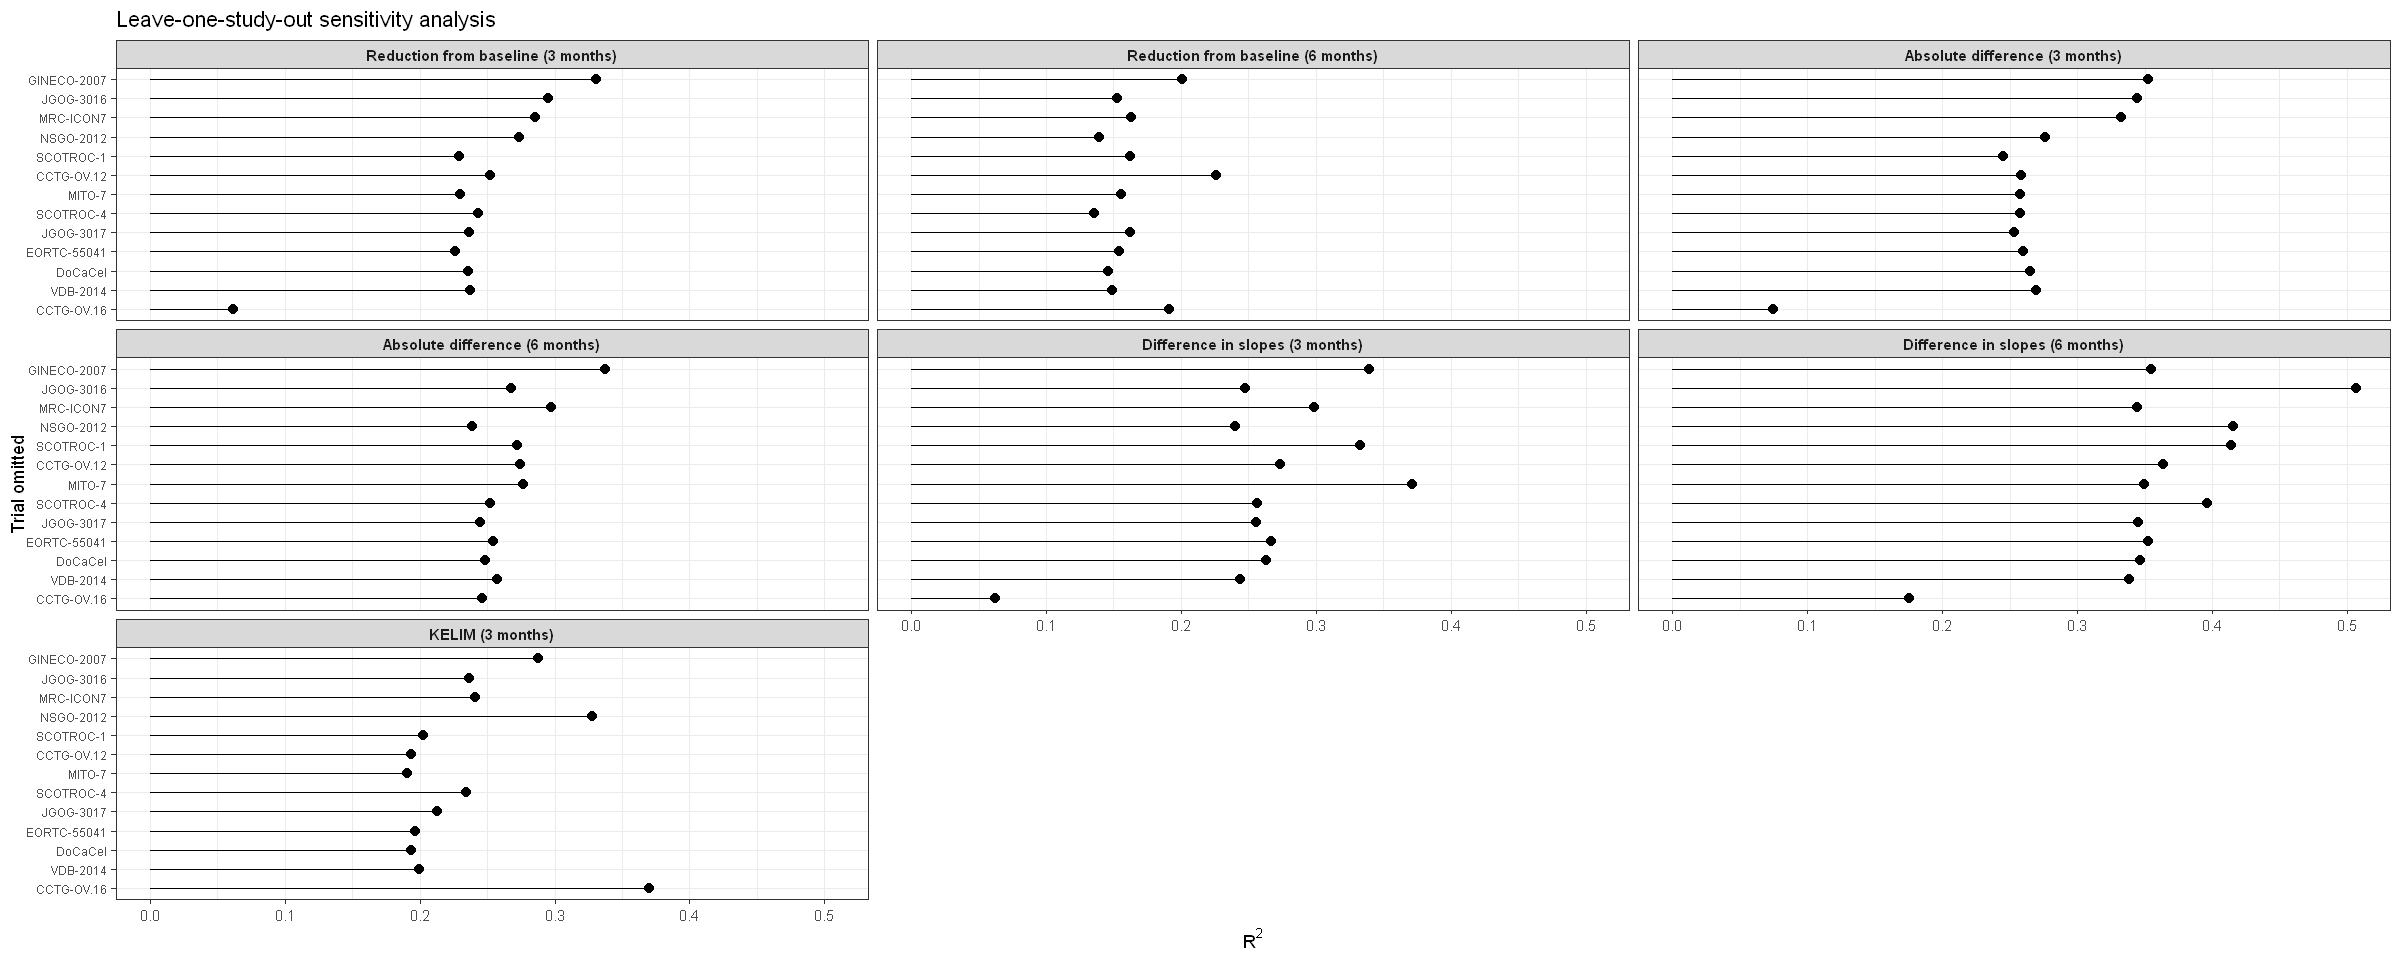

In [ ]:
plot_df <- loso_boot_r2 %>%
  filter(summary %in% c(
    "pct3",
    "abs3",
    "slope3",
    "pct6",
    "abs6",
    "slope6",
    "delta_kelim"
  )) %>%
  mutate(
    summary = factor(
      summary,
      levels = c(
        "pct3",
        "pct6",
        "abs3",
        "abs6",
        "slope3",
        "slope6",
        "delta_kelim"
      ),
      labels = c(
        "Reduction from baseline (3 months)",
        "Reduction from baseline (6 months)",
        "Absolute difference (3 months)",
        "Absolute difference (6 months)",
        "Difference in slopes (3 months)",
        "Difference in slopes (6 months)",
        "KELIM (3 months)"
      )
    )
  )

ggplot(
  plot_df,
  aes(
    x = reorder(left_out_trial, R2),
    y = R2
  )
) +
  geom_segment(
    aes(
      xend = left_out_trial,
      y = 0,
      yend = R2
    )
  ) +
  geom_point(size = 2.5) +
  coord_flip() +
  facet_wrap(~summary, ncol = 3, scales = "fixed") +
  labs(
    x = "Trial omitted",
    y = expression(R^2),
    title = "Leave-one-study-out sensitivity analysis"
  ) +
  theme_bw() +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.y = element_text(size = 7)
  )

In [ ]:
# ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
# ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]
# f1 <- function(x) predict(ns_basis, x)[,1]
# f2 <- function(x) predict(ns_basis, x)[,2]
# f3 <- function(x) predict(ns_basis, x)[,3]
# ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
# ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]

In [ ]:

# formLong <- log_ca125 ~ f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+ (f1(time_ca125) + f2(time_ca125)+ f3(time_ca125) |id_num)+(trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)|trialid_num)
# formSurv <- INLA::inla.surv(pfs_time_d, pfs_statut) ~ trt_bin
# model_setup <- joint(
#   formSurv  = list(formSurv),
#   formLong  = list(formLong),
#   dataSurv  = as.data.frame(ca125_all_6),
#   dataLong  = as.data.frame(ca125_all_6),
#   id        = "id_num",
#   timeVar   = "time_ca125",
#   family    = "gaussian",
#   basRisk   = "rw2", 
#   NbasRisk = 50,
#   assoc     = "CS",
#   control   = list(int.strategy = "eb"),
#   run=FALSE
# )

In [ ]:
# # Stacking lengths
# N <- length(model_setup$.args$data$Yjoint[[1]])
# n_long <- nrow(ca125_all_6)
# N <- length(model_setup$.args$data$Yjoint[[1]])
# pad <- rep(NA, N - n_long)

# # Treatment * splines random effects
# model_setup$.args$data$WTrial1 <-c(ca125_all_6$trt_bin * f1(ca125_all_6$time_ca125), pad)
# model_setup$.args$data$WTrial2 <-c(ca125_all_6$trt_bin * f2(ca125_all_6$time_ca125), pad)
# model_setup$.args$data$WTrial3 <-c(ca125_all_6$trt_bin * f3(ca125_all_6$time_ca125), pad)

# # Priors
# prior_prec <- list(prior = "loggamma",param = c(1.5, 0.5))

# # Set environnement
# environment(model_setup$.args$formula)$WTrial1 <- model_setup$.args$data$WTrial1
# environment(model_setup$.args$formula)$WTrial2 <- model_setup$.args$data$WTrial2
# environment(model_setup$.args$formula)$WTrial3 <- model_setup$.args$data$WTrial3
# environment(model_setup$.args$formula)$n_trials <- n_trials
# environment(model_setup$.args$formula)$prior_prec <- prior_prec

# # Add the trial-level random effects to the formula
# model_setup$.args$formula <- update(
#   model_setup$.args$formula,
#   ~ . +f(WTrial1, model = "iid", n = max(model_setup$.args$data$WTrial1), constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(WTrial2, model = "iid", n = max(model_setup$.args$data$WTrial2), constr = FALSE, hyper = list(prec = prior_prec)) +
#     f(WTrial3, model = "iid", n = max(model_setup$.args$data$WTrial3), constr = FALSE, hyper = list(prec = prior_prec))
# )

# # run the model
# model_fit <- joint.run(model_setup)
# saveRDS(model_fit, file = "jointed_inla_pfs.rds")


In [ ]:
# # model
# model_fit <- readRDS("jointed_inla_pfs.rds")
# # print summary
# print(summary(model_fit, sdcor=TRUE))

In [ ]:
# inla.zmarginal(inla.tmarginal(function(x) sqrt(1/x), model_fit$marginals.hyperpar[["Precision for WTrial3"]]))

In [ ]:
# ca125_all_6$pfs_statut <- as.numeric(as.character(ca125_all_6$pfs_statut))
# ca125_all_6_surv$pfs_statut <- as.numeric(as.character(ca125_all_6_surv$pfs_statut))
# ca125_all_6$id_num <- as.integer(factor(ca125_all_6$id_num))
# ca125_all_6_surv$id_num <- as.integer(factor(ca125_all_6_surv$id_num))
# P <- predict(
#   model_fit,
#   newData = ca125_all_6,        # longitudinal only
#   newDataSurv = ca125_all_6_surv, # survival only (ONE row per id)
#   horizon = 550,
#   survival = TRUE
# )
# str(P)